In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="5" color="red"><b>ch2. 군집분석</b></font>
# 1절. 군집모델(클러스터링)
- 클러스터(cluster) : 독립변수의 특성이 유사한 데이터의 그룹
- 클러스터링(clustering) : 주어진 데이터를 여러 개의 클러스터로 구분하는 것
1) 중심 기반 클러스터링(K-Means) : https://commons.wikimedia.org/wiki/File:KMeans-Gaussiandata.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/e/e5/KMeans-Gaussian-data.svg"
style="display: block; margin-left: 0; width: 20%;">
2) 연결기반 클러스터링(DBSCAN) : https://commons.wikimedia.org/wiki/File:DBSCAN-densitydata.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/0/05/DBSCAN-density-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">
3) 밀도기반 클러스터링(DBSCAN의 변형으로 OPTICS) :
https://commons.wikimedia.org/wiki/File:OPTICS-Gaussian-data.svg
<img src="https://upload.wikimedia.org/wikipedia/commons/8/8a/OPTICS-Gaussian-data.svg"
width="300"
style="display: block; margin-left: 0; width: 20%;">

# 2절. K-Means 클러스터링
- 가장 단순하고 빠른 클러스터링 알고리즘의 하나
- 목적함수 값이 최소화될 때까지 클러스터의 중심(centroid) 𝜇k와 각 데이터가 소속될 클러스터를 반복해서 찾는 것  

K-Means 클러스터링의 세부 알고리즘
1. 임의의 중심값 μk를 고릅니다.(보통 데이터 샘플 중의 하나를 선택합니다.)
2. 중심에서 각 샘플 데이터까지의 거리를 계산합니다.
3. 각 데이터 샘플에서 가장 가까운 중심을 선택하여 클러스터 갱신합니다.
4. 다시 만들어진 클러스터에 대해 중심을 다시 계산하고 1~4를 반복합니다.

In [2]:
import matplotlib.pyplot as plt
# plt.rc('font', family='Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic' # 한글깨짐 방지
plt.rcParams['axes.unicode_minus'] = False  # 축의 - 깨짐 방지
plt.rcParams['figure.figsize'] = (10,4) # 모든 시각화 사이즈

In [3]:
# 분류를 위한 가상 데이터 셋 생성
from sklearn.datasets import make_classification
X, y = make_classification(
                          n_samples=20, # 데이터 개수(기본값100) : 20행
                          n_features=2, # 독립변수 개수(기본값20)
                          n_informative=2, # 독립변수 중 종속변수에 영향을 주는 독립변수 개수(기본값2)
                          n_redundant=0, # 종속변수에 영향을 안 미치는 독립변수 개수(기본값2)
                          n_classes=2, # 종속변수의 클래스 수(0, 1)
                          n_clusters_per_class=1, # 각 클래스 당 군의 개수(서브그룹이 없음)
                          random_state=123
)
X.shape, y.shape

((20, 2), (20,))

In [4]:
# 5:5로 분류되었는지 확인
import numpy as np
value, count = np.unique(y, return_counts=True)
{v:c for v, c in zip(value, count)}

{0: 10, 1: 10}

In [5]:
np.column_stack([X,y])[:3] # np.c_[X, y]

array([[ 1.03859554,  2.51175389,  0.        ],
       [ 1.00271366,  1.93521549,  0.        ],
       [-1.6881048 ,  0.02599427,  1.        ]])

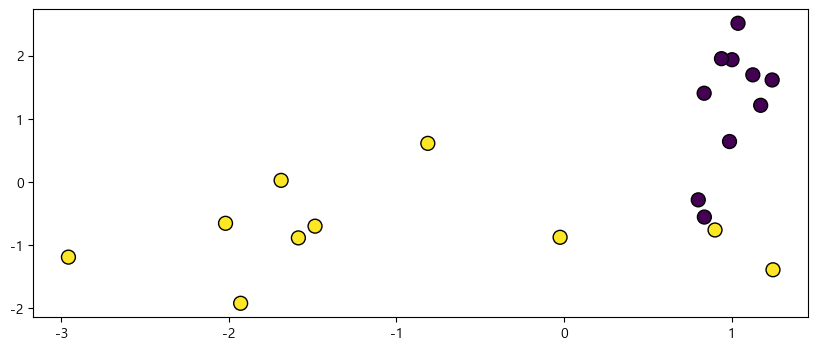

In [6]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k')
plt.show()

In [7]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters=2, # 군의 개수
                            init='k-means++', # 초기중심점이 서로 멀리 떨어지도록 똑똑하게 초기화/'random'
                            max_iter=300, # 각 실행에서 최대 300번 중심점 이동(중심점이 이동되지 않으면 300까지 안해)
                            n_init='auto'
              )
model.fit(X)

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [8]:
c0, c1 = model.cluster_centers_ # 모델이 선정한 두 클러스터의 중심점
c0, c1

(array([-0.72607008, -0.71382205]), array([1.04359173, 1.62105848]))

In [9]:
print('실제값 :', y)
pred = model.predict(X)
print('예측값 :', pred)
labels = model.labels_
print('라  벨 :', labels)

실제값 : [0 0 1 1 0 1 0 1 1 0 0 0 0 1 1 1 1 1 0 0]
예측값 : [1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1]
라  벨 : [1 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0 0 1 1]


In [10]:
# 0그룹으로 라벨링
X[labels==0]

array([[-1.6881048 ,  0.02599427],
       [ 0.90134424, -0.75896558],
       [-0.02317631, -0.87481215],
       [ 0.83780453, -0.554389  ],
       [-1.9295722 , -1.91894047],
       [-0.8124957 ,  0.61140818],
       [ 0.80138648, -0.28232585],
       [-1.48554751, -0.69890985],
       [ 1.24732102, -1.38872822],
       [-2.95714561, -1.18843377],
       [-1.5849172 , -0.88425569],
       [-2.0197379 , -0.65350646]])

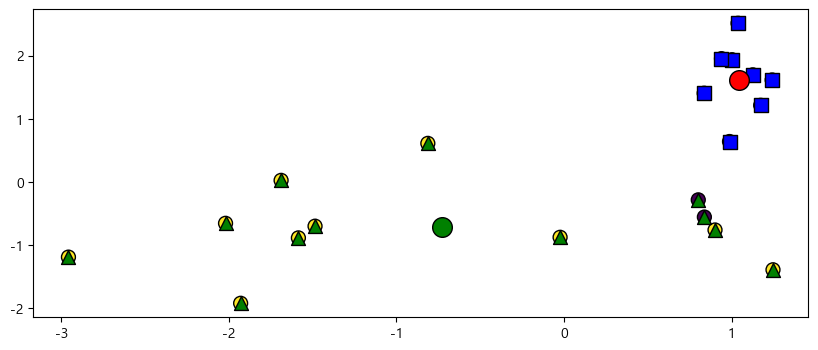

In [11]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=100, edgecolors='k')
plt.scatter(X[labels==0, 0], X[labels==0, 1], marker='^', c='g', edgecolors='k', s=100)
plt.scatter(X[labels==1, 0], X[labels==1, 1], marker='s', c='b', edgecolors='k', s=100)
plt.scatter(c0[0], c0[1], c='g', s=200, edgecolors='k')
plt.scatter(c1[0], c1[1], c='r', s=200, edgecolors='k')

In [12]:
# X데이터를 Normalizer를 이용한 변환
import pandas as pd
from sklearn.preprocessing import Normalizer
scaler = Normalizer()
Xnor = scaler.fit_transform(X)
pd.concat([pd.DataFrame(X, columns=['x0', 'x1']),
          pd.DataFrame(Xnor, columns=['x0_nor', 'x1_nor'])],
          axis=1 )

,x0,x1,x0_nor,x1_nor
0,1.038596,2.511754,0.382116,0.924114
1,1.002714,1.935215,0.460053,0.887892
2,-1.688105,0.025994,-0.999881,0.015397
3,0.901344,-0.758966,0.764937,-0.644105
4,0.836531,1.404882,0.511615,0.859215
5,-0.023176,-0.874812,-0.026484,-0.999649
6,0.837805,-0.554389,0.833951,-0.551839
7,-1.929572,-1.918940,-0.709057,-0.705151
8,-0.812496,0.611408,-0.799038,0.601281
9,1.126947,1.695701,0.553503,0.832847


## K-means 클러스터링의 한계(pdf 13p)
- 군의 특성이 다를 경우
    * 크기(sizes)
    * 밀도(Densities)
    * 비 구형(Non-globular shapes)
- 이상치를 포함할 경우 이상치를 없애고 클러스터링 진행

### 군의 크기가 다를 경우

In [13]:
# np.random.normal(평균, 표준편차, size)
group0 = np.random.normal(-10, 2, (10,2))
y0 = np.full(group0.shape[0], 0)
group0 = np.c_[group0, y0]
group0[:3]

array([[ -7.90480516, -10.9066235 ,   0.        ],
       [-13.08687245,  -8.44904417,   0.        ],
       [ -9.69341094,  -9.54618588,   0.        ]])

In [14]:
# group1 : 평균0
group1 = np.random.normal(-10, 2, (10,2))
y1 = np.full(group0.shape[0], 1)
group1 = np.c_[group1, y1]
group1[:3]

array([[ -7.30246799, -11.35249217,   1.        ],
       [-11.85531518, -12.617055  ,   1.        ],
       [-11.10251662,  -9.83797533,   1.        ]])

In [15]:
# group2 : 평균0, 표준편차 5인 100행 2열 데이터
group2 = np.random.normal(0, 5, (100,2))
y2 = np.full(group2.shape[0], 2)
group2 = np.c_[group2, y2]
group2[:3]

array([[ 2.62298391, -2.5772576 ,  2.        ],
       [-0.84351241, -1.7937862 ,  2.        ],
       [ 0.72862879,  2.07823391,  2.        ]])

In [16]:
data = np.r_[group0, group1, group2] # 120행3열
data[::10]

array([[ -7.90480516, -10.9066235 ,   0.        ],
       [ -7.30246799, -11.35249217,   1.        ],
       [  2.62298391,  -2.5772576 ,   2.        ],
       [  0.6330997 ,  -1.31989745,   2.        ],
       [  1.02643146,  -9.7757427 ,   2.        ],
       [ -3.34839135, -10.47158636,   2.        ],
       [  5.5899076 ,   7.11850558,   2.        ],
       [ -4.99350294,  -4.03347852,   2.        ],
       [  2.30309207,   0.65865552,   2.        ],
       [  4.69962697,  -2.6781208 ,   2.        ],
       [ -4.47039078,  -6.02044638,   2.        ],
       [ -3.08676095,  -3.30746503,   2.        ]])

In [17]:
group0.shape, group1.shape, group2.shape, data.shape

((10, 3), (10, 3), (100, 3), (120, 3))

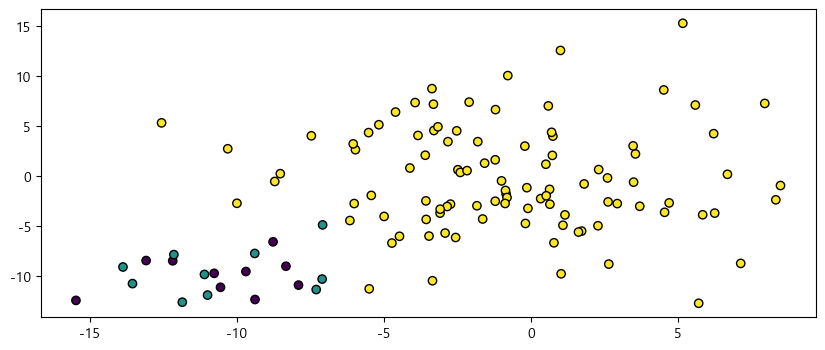

In [18]:
plt.scatter(data[:, 0],  data[:, 1], c=data[:, 2], edgecolors='k')
plt.show()

In [19]:
# 3개 그룹으로 클러스터링
model = KMeans(n_clusters=3, n_init=5)
model.fit(data[:, :2])

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,5
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [20]:
labels = model.labels_ # 모델이 구분한 군들
labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 2, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 0,
       0, 0, 1, 0, 1, 2, 1, 1, 0, 1, 1, 2, 2, 0, 0, 1, 0, 0, 0, 0, 2, 1,
       1, 2, 1, 1, 0, 1, 0, 1, 1, 0])

In [21]:
centers = model.cluster_centers_ # 군의 중심점

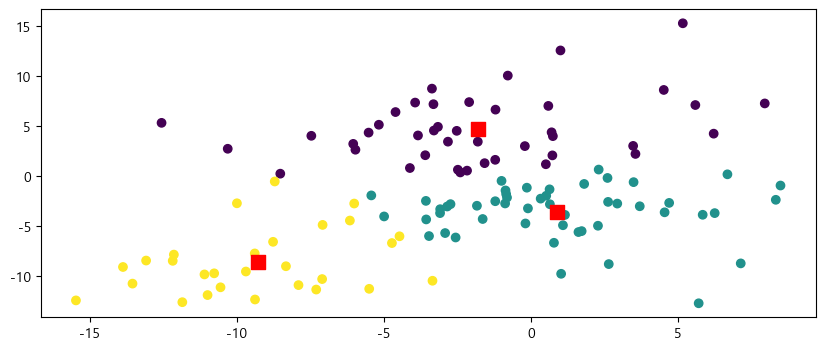

In [22]:
plt.scatter(data[:, 0], data[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], c='r', s=100, marker='s')

In [23]:
# 6개 그룹으로 클러스터링
model = KMeans(n_clusters=6, n_init=5)
model.fit(data[:, :2])

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,6
,init,'k-means++'
,n_init,5
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [24]:
labels = model.labels_
labels1 = model.predict(data[:, :2])
np.all(labels==labels1)

True

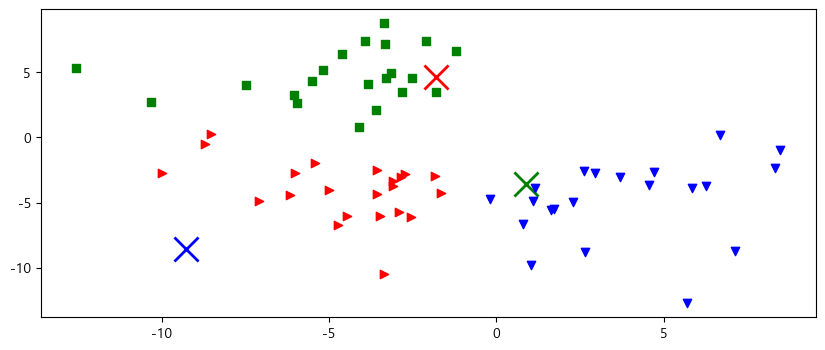

In [25]:
colors = ['r', 'g', 'b', 'c', 'm', 'k'] # m:마젠다(보라핑크)
markers = ['>','s','v','^','x','<']
for i, c in enumerate(centers):
    #print(i, c[0], c[1], data[labels==i][:2])
    plt.scatter(x = data[labels==i, 0], y = data[labels==i, 1], c= colors[i], marker=markers[i])
    plt.scatter(c[0], c[1], s=300, c=colors[i], marker='x', linewidths=2)
# 3/ 1, 2, 4, 5 / 0

# 3절. Hierachical 클러스터링(계층적 군집)
- 비슷한 군끼리 묶으면서 하나의 군집이 될 때까지 군을 묶는 알고리즘
- 군집간의 거리를 기반으로 클러스터링을 하는 알고리즘
- 군집의 수를 미리 정해주지 않아도 됨
- dendrogram이라는 그래프를 이용하면 손쉽게 시각화

In [26]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [27]:
# 계층적 군집화를 위해 라벨 인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris['species'] = le.fit_transform(iris['species'])
iris.iloc[::50]

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
50,7.0,3.2,4.7,1.4,1
100,6.3,3.3,6.0,2.5,2


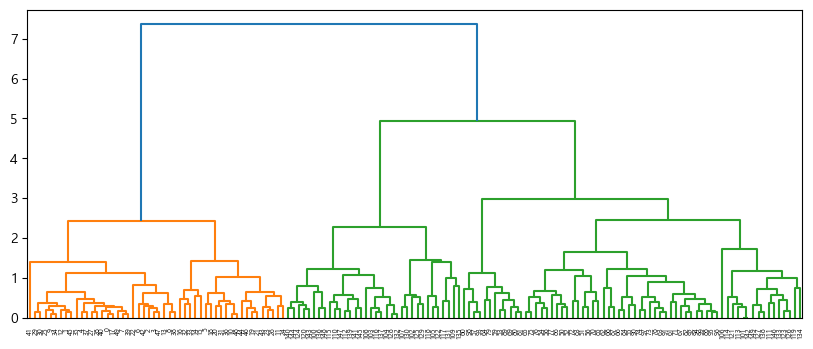

In [28]:
from scipy.cluster.hierarchy import linkage, dendrogram
# method : 각 클러스터 간 거리를 어떻게 계산할지
cluster_model = linkage(iris, method='complete') # 두 클러스터에서 가장 먼 거리를 이용해서 측정
dendrogram(cluster_model, labels=iris.index)
# 파일 저장
plt.savefig('data/ch2_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show() # 화면출력

In [29]:
# 클러스트 생성하는 함수
from scipy.cluster.hierarchy import fcluster
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        6, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [30]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        4, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [31]:
fcluster(cluster_model, # linkage()로 만든 클러스터링 결과(모델)
        2, # 클러스터를 나누는 임계값
        criterion='distance')

array([1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 2, 2, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 1, 2, 1, 6, 6, 6, 5, 6, 6, 6, 5, 6, 5, 5, 6, 6, 6, 5, 6,
       6, 6, 6, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 5, 6, 6, 6, 5, 6, 6, 6, 6, 5, 6, 3, 7, 4, 3, 3, 4, 7, 4, 3, 4,
       3, 7, 3, 7, 7, 3, 3, 4, 4, 7, 3, 7, 4, 7, 3, 4, 7, 7, 3, 4, 4, 4,
       3, 7, 7, 4, 3, 3, 7, 3, 3, 3, 7, 3, 3, 3, 7, 3, 3, 7], dtype=int32)

In [32]:
fcluster(cluster_model,
        2, # 클러스터의 개수
        criterion='maxclust')

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [33]:
pred = fcluster(cluster_model, 4, criterion='distance')
pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2,
       2, 3, 2, 3, 3, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 3, 3, 2, 2, 2, 2,
       2, 3, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 2, 3, 2, 2, 3], dtype=int32)

In [34]:
# 위의 pred을 치환하는 문법
np.choose([1, 1, 3, 3, 2, 2], [0, 0, 2, 1])

array([0, 0, 1, 1, 2, 2])

In [35]:
adjusted_pred = np.choose(pred, [9, 0, 2, 1])
adjusted_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 1, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [36]:
pred_name = le.inverse_transform(adjusted_pred)
original_name = le.inverse_transform(iris['species'])
pd.crosstab(original_name, pred_name, rownames=['실제값'], colnames=['예측값'], 
            margins=True) # 행과 열의 총계 추가

예측값,setosa,versicolor,virginica,All
실제값,,,,
setosa,50,0,0,50
versicolor,0,50,0,50
virginica,0,16,34,50
All,50,66,34,150


<Axes: xlabel='petal_length', ylabel='petal_width'>

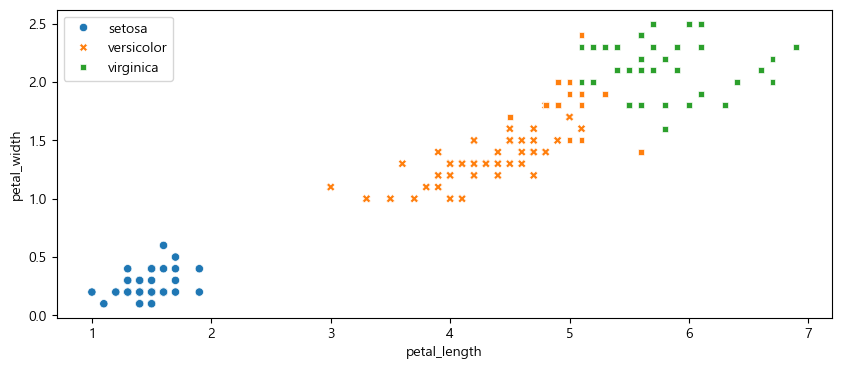

In [37]:
import seaborn as sns
sns.scatterplot(data=iris,
               x='petal_length',
               y='petal_width',
               hue=pred_name,
               style=original_name)

# 4절. DBSCAN 클러스터링
- 연결기반(밀도기반)군집화 알고리즘 (클러스터 수를 미리 정할 필요없음. 이상차를 자동감지)
- 단점 : 클러스터의 밀도가 일정하지 않으면 성능 떨어짐
- eps(반경)과 min_sampels(최소샘플수)를 적절히 조절하여 군집화

In [38]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0<=x<1의 균등포 난수 n개 발생
noise = np.random.normal(0, 0.2, X1.shape)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(X1.shape[0], 0)]

X2 = X1 + 1.5
noise = np.random.normal(0, 0.2, X1.shape)
Y2 = np.cos(X2)+noise
group2 = np.c_[X2, Y2, np.ones(X2.shape[0])]

data = np.r_[group1, group2]
data[::100]

array([[ 1.57367237,  1.27473906,  0.        ],
       [ 2.87509797,  0.20593475,  0.        ],
       [ 3.07367237, -0.93665668,  1.        ],
       [ 4.37509797, -0.32641027,  1.        ]])

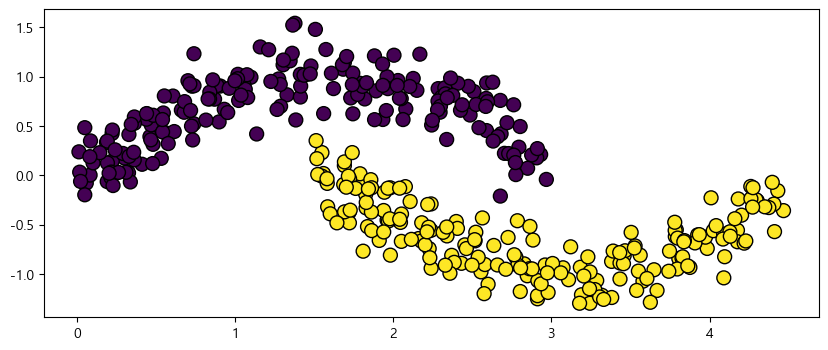

In [39]:
plt.scatter(data[:,0], data[:,1], c=data[:,2], s=100, edgecolors='k')
plt.show()

In [40]:
model = KMeans(n_clusters=2, n_init=5)
model.fit(data[:, :2])

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,5
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [41]:
labels=model.labels_ # 군집화 결과
centers = model.cluster_centers_ # 중심점

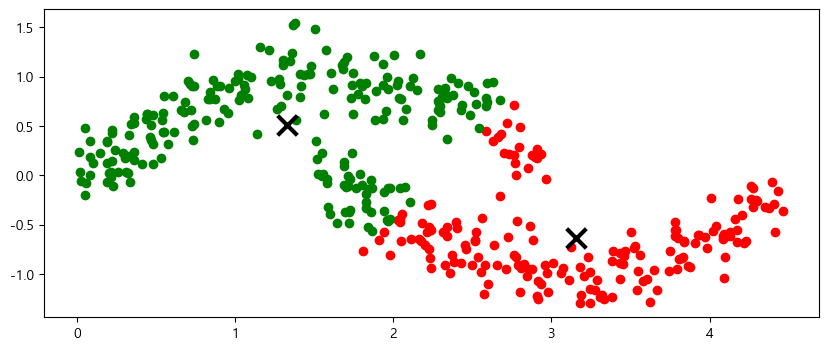

In [42]:
data[labels==1]
colors = ['r','g']
for i, c in enumerate(centers):
    #print(i, c[0], c[1])
    plt.scatter(data[labels==i, 0],
               data[labels==i, 1],
               c=colors[i])
    plt.scatter(c[0], c[1], c='k', marker='x', s=200, lw=3)

# 5절. 군집모형 성능평가
- 예측 모형의 score(분류, 회귀)
    * score메소드를 통해서 예측 모형의 정확도를 평가
- metrics 패키지
    * 분류분석 recall, precision을 평가하는 함수
    * 군집 모형등의 평가를 위한 함수
- scoring 매개변수
    * GridSearchCV클래스-> 4장

In [43]:
from seaborn import load_dataset
iris = load_dataset('iris')
iris_X = iris.iloc[:, :-1]
iris_y = iris.iloc[:, -1]

In [44]:
from sklearn.cluster import KMeans
iris_3cluster_model = KMeans(n_clusters=3, random_state=1, n_init=10)
iris_3cluster_model.fit(iris_X)

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


KMeans(n_clusters=3, n_init=10, random_state=1)
In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.

In [45]:
# pred3 = iris_3cluster_model.labels_
pred3 = iris_3cluster_model.predict(iris_X)
pred3

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [46]:
pred3_str = np.choose(pred3, ['versicolor','setosa','virginica']) # 모델이 군집화한 데이터
# 군집분석의 성능 평가 함수를 쓰기 위해서 pred3_str(넘파이배열)과 iris_y(시리즈)

In [47]:
# iris_y를 라벨인코딩
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
iris_y3 = le.fit_transform(iris_y)
pred3 = np.choose(pred3, [1,0,2])

# 군집분석의 성능 평가 함수를 쓰기 위해 pred3과 iris_y3(둘다 넘파이배열)

In [48]:
pd.crosstab(iris_y, pred3_str)

col_0,setosa,versicolor,virginica
species,,,
setosa,50,0,0
versicolor,0,48,2
virginica,0,14,36


In [49]:
from sklearn.cluster import KMeans
iris_2cluster_model = KMeans(n_clusters=2, random_state=1, n_init=10)
iris_2cluster_model.fit(iris_X)

C:\Users\mbc1\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,2
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,1
,copy_x,True
,algorithm,'lloyd'


In [50]:
# pred2 = iris
pred2 = iris_2cluster_model.predict(iris_X)

In [51]:
iris_y2 = np.array([0]*50 + [1]*100)
# 군집분석의 성능 평가 함수를 쓰기 위해 pred2와 iris_y2(둘다 넘파이 배열)

In [52]:
pred2_str = np.choose(pred2, ['setosa', '그외'])
iris_y2_str = np.choose(iris_y2, ['setosa', '그외'])
# 군집분석의 성능 평가 함수를 쓰기 위해 pred2_str와 iris_y2_str(둘다 넘파이 배열)

In [53]:
pd.crosstab(iris_y2_str, pred2_str)

col_0,setosa,그외
row_0,,
setosa,0,50
그외,97,3


In [54]:
pred3_str.shape, iris_y.shape, pred3.shape, iris_y3.shape      # 3개 클러스터

((150,), (150,), (150,), (150,))

In [55]:
pred2.shape, iris_y2.shape, pred2_str.shape, iris_y2_str.shape # 2개 클러스터

((150,), (150,), (150,), (150,))

## 5.1 조정된 rand 지수
- 조정된 랜드지수는 pred, iris_y이 얼마나 같은 쌍을 만들어내는지

In [56]:
# 클러스터개수가 3개인 경우 성능 평가
from sklearn.metrics import adjusted_rand_score
adjusted_rand_score(labels_true=iris_y,
                   labels_pred=pred3_str)

0.7302382722834697

In [57]:
adjusted_rand_score(labels_true=iris_y3,
                   labels_pred=pred3)

0.7302382722834697

In [58]:
# 클러스터개수가 2개인 경우 성능 평가
adjusted_rand_score(labels_true=iris_y2,
                   labels_pred=pred2)

0.920405050901892

In [59]:
adjusted_rand_score(labels_true=iris_y2_str,
                   labels_pred=pred2_str)

0.920405050901892

## 5.2 상호 의존도를 나타내는 지표

In [60]:
from sklearn.metrics import mutual_info_score
# 클러스터가 3인 경우 : 클러스터 개수가 높으면 잘나오는 경향이 있음. -> 정규화된 mutual_info_score
print(mutual_info_score(iris_y, pred3_str))
print(mutual_info_score(iris_y3, pred3))

0.8255910976103356
0.8255910976103356


In [61]:
# 클러스터가 2인 경우
print(mutual_info_score(iris_y2, pred2))
print(mutual_info_score(iris_y2_str, pred2_str))

0.5596576064224734
0.5596576064224734


In [62]:
from sklearn.metrics import normalized_mutual_info_score
print(normalized_mutual_info_score(iris_y, pred3_str))
print(normalized_mutual_info_score(iris_y3, pred3))

0.7581756800057784
0.7581756800057784


In [63]:
# 클러스터가 2인 경우
print(normalized_mutual_info_score(iris_y2, pred2))
print(normalized_mutual_info_score(iris_y2_str, pred2_str))

0.8703851565631638
0.8703851565631638


## 5.3 그 외 클러스터링 성능 평가 기준 함수들

In [64]:
from sklearn.metrics import homogeneity_score
print(homogeneity_score(iris_y, pred3_str))
print(homogeneity_score(iris_y3, pred3))

0.7514854021988338
0.7514854021988338


In [65]:
print(homogeneity_score(iris_y2, pred2))
print(homogeneity_score(iris_y2_str, pred2_str))

0.8792539652679946
0.8792539652679946


In [66]:
from sklearn.metrics import completeness_score
print(completeness_score(iris_y, pred3)) # 클러스터 3
print(completeness_score(iris_y2, pred2)) # 클러스터 2

0.7649861514489815
0.861693475999054


In [67]:
from sklearn.metrics import v_measure_score
print(v_measure_score(iris_y, pred3))
print(v_measure_score(iris_y2, pred2))

0.7581756800057784
0.870385156563164


## 5.4 실루엣 계수
- 앞의 경우 클러스터의 개수와 소속을 알고 있을 경우 평가하는 방법
- 아래의 경우는 클러스터의 개수와 소속을 모르고 있을 경우 평가하는 방법

In [68]:
import numpy as np
X1 = np.random.rand(200)*3 # rand(n) : 0<=x<1의 균등포 난수 n개 발생
noise = np.random.normal(0, 0.2, X1.shape)
Y1 = np.sin(X1) + noise
group1 = np.c_[X1, Y1, np.full(X1.shape[0], 0)]

X2 = X1 + 1.5
noise = np.random.normal(0, 0.2, X1.shape)
Y2 = np.cos(X2)+noise
group2 = np.c_[X2, Y2, np.ones(X2.shape[0])]

data = np.r_[group1, group2]
data[::100]

array([[ 2.32404084,  0.98333274,  0.        ],
       [ 0.54864808,  0.49648881,  0.        ],
       [ 3.82404084, -0.78988044,  1.        ],
       [ 2.04864808, -0.32900571,  1.        ]])

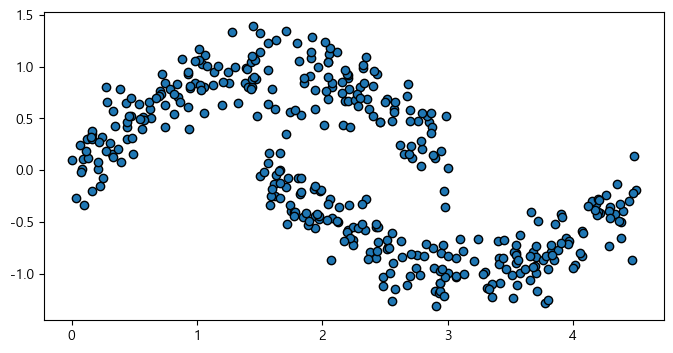

In [69]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(action='ignore')
plt.figure(figsize=(8,4))
plt.scatter(x = data[:, 0], y=data[:,1], edgecolors='k')
plt.show()

In [77]:
# 실루엣 계수
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
range_n_clusters = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=3)
#     model.fit(data[:, :-1])
#     cluster_labels = model.labels_
#     cluster_labels = model.predict(data[:, :-1])
    cluster_labels = model.fit_predict(data[:, :-1])
    # cluster_labels의 성능 지표 : 실루엣 계수
    score = silhouette_score(data[:, :-1], # 학습 데이터
                            cluster_labels)            # 결과 클러스터 레이블
    print(f'클러스터수가 {n_clusters}일 때, 실루엣 계수는 {score}')

클러스터수가 2일 때, 실루엣 계수는 0.5046834011126758
클러스터수가 3일 때, 실루엣 계수는 0.46946522495483073
클러스터수가 4일 때, 실루엣 계수는 0.4903608416703962
클러스터수가 5일 때, 실루엣 계수는 0.4850387524142977
클러스터수가 6일 때, 실루엣 계수는 0.49127673737454
클러스터수가 7일 때, 실루엣 계수는 0.49138938796751946
클러스터수가 8일 때, 실루엣 계수는 0.4862099469950779
클러스터수가 9일 때, 실루엣 계수는 0.47289209104179764
클러스터수가 10일 때, 실루엣 계수는 0.4619645954790203
클러스터수가 11일 때, 실루엣 계수는 0.4489051047240142
클러스터수가 12일 때, 실루엣 계수는 0.431628137405353


# 6절. 연습문제
1. iris의 데이터의 petal_length열과 petal_widtg열을 이용해서 K-Means 알고리즘으로 군집분석하였을 때,  
최적의 클러스터 수를 실루엣 계수를 이용하여 분석하세요
- 단, 각 클러스터의 중심점이 함께 표시되고 군의 수는 2와 3으로 설정하여 시각화하고 실루엣 계수를 비교
- 분석한 결과로 시각화하세요

In [87]:
from seaborn import load_dataset
iris = load_dataset('iris')
data = iris[['petal_length', 'petal_width']]
data = iris.iloc[:, 2:4].to_numpy()

In [88]:
range_n_clusters = [2,3,4,5]
scores = []
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=n_clusters, n_init=10)
    cluster_labels = model.fit_predict(data)
    score = silhouette_score(data,  # 학습 데이터
                            cluster_labels) # 결과 클러스터 레이블
    scores.append(score)
    print(f'클러스터수가 {n_clusters}일 때, 실루엣 계수는 {score:.5f}')

클러스터수가 2일 때, 실루엣 계수는 0.76539
클러스터수가 3일 때, 실루엣 계수는 0.66048
클러스터수가 4일 때, 실루엣 계수는 0.61276
클러스터수가 5일 때, 실루엣 계수는 0.58837


In [ ]:
model = KMeans(n_clusters=2, n_init=10)
labels = model.fit_predict(data)
centers = model.cluster_centers_ # 중심점
colors = ['r','g','b','c','m']
for i, c in enumerate(centers):
    plt.scatter(data.iloc[labels==i, 0], 
                data.iloc[labels==i, 1], c=colors[i])
plt.scatter(centers[:,0], centers[:,1], c='k', marker='x', s=100, lw=5)
plt.show()

In [ ]:
model = KMeans(n_clusters=3, n_init=10)
labels = model.fit_predict(data)
centers = model.cluster_centers_ # 중심점
colors = ['r','g','b','c','m']
for i, c in enumerate(centers):
    plt.scatter(data.iloc[labels==i, 0], 
                data.iloc[labels==i, 1], c=colors[i])
plt.scatter(centers[:,0], centers[:,1], c='k', marker='x', s=100, lw=5)
plt.show()

In [ ]:
model = KMeans(n_clusters=4, n_init=10)
labels = model.fit_predict(data)
centers = model.cluster_centers_ # 중심점
colors = ['r','g','b','c','m']
for i, c in enumerate(centers):
    plt.scatter(data.iloc[labels==i, 0], 
                data.iloc[labels==i, 1], c=colors[i])
plt.scatter(centers[:,0], centers[:,1], c='k', marker='x', s=100, lw=5)
plt.show()

In [ ]:
model = KMeans(n_clusters=5, n_init=10)
labels = model.fit_predict(data)
centers = model.cluster_centers_ # 중심점
colors = ['r','g','b','c','m']
for i, c in enumerate(centers):
    plt.scatter(data.iloc[labels==i, 0], 
                data.iloc[labels==i, 1], c=colors[i])
plt.scatter(centers[:,0], centers[:,1], c='k', marker='x', s=100, lw=5)
plt.show()

In [ ]:
range_n_clusters = [2,3,4,5]
for n_clusters in range_n_clusters:
    model = KMeans(n_clusters=5, n_init=10)
    labels = model.fit_predict(data)
    centers = model.cluster_centers_ # 중심점
    colors = ['r','g','b','c','m']
    for i, c in enumerate(centers):
        plt.scatter(data.iloc[labels==i, 0], 
                    data.iloc[labels==i, 1], c=colors[i])
    plt.scatter(centers[:,0], centers[:,1], c='k', marker='x', s=100, lw=5)
    plt.show()

In [ ]:
plt.plot(range_n_clusters, scores, color='gray', linewidth=2,)
plt.scatter(range_n_clusters[0], scores[0], color='b', linewidth=2, marker='o')
plt.scatter(range_n_clusters[1:], scores[1:], color='orange', linewidth=2, marker='o')
# 각 점 위에 점수 값 표시
for x, y in zip(range_n_clusters, scores):
    plt.text(x, y + 0.02, f'{y:.3f}', ha='center')

plt.title('Mean silhouette score')
plt.xlabel('Number of clusters (k)')
plt.ylim(min(scores)-0.05, max(scores)+0.05)
plt.xticks(range_n_clusters)
plt.grid(axis='y')
ax = plt.gca()  # 현재 그래프의 축(axes) 객체 가져오기(spines함수 때문에)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('gray')
plt.show()